In [3]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()
library(ComplexHeatmap)
library(circlize)

Loading required package: grid

ComplexHeatmap version 2.14.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))
! pheatmap() has been masked by ComplexHeatmap::pheatmap(). Most of the arguments
   in the original pheatmap() are identically supported in the new function. You 
   can still use the original function by explicitly calling pheatmap::pheatmap().



Attaching package: ‘Co

In [4]:
orfs_path <- "../../results/all_samples.ibaq_b_with_total.tsv"
fread_c(orfs_path) -> orfs
colnames(orfs)
head(orfs,1)
n_distinct(orfs$Sample)

[1] "ORF_id"                      "iBAQ_B"                     
 [3] "iBAQ_A"                      "Available"                  
 [5] "TotalIntensity"              "ORF_type"                   
 [7] "Start_codon"                 "Isoform_id"                 
 [9] "Chr"                         "Strand"                     
[11] "ORF_seq"                     "ORF_length"                 
[13] "Geneid"                      "Isoform_structural_category"
[15] "Isoform_subcategory"         "is_uniprot"                 
[17] "is_canonical"                "All_peptide_n"              
[19] "Unique_peptide_n"            "Theo_peptide_n"             
[21] "Sample"

,ORF_id,iBAQ_B,iBAQ_A,Available,TotalIntensity,ORF_type,Start_codon,Isoform_id,Chr,Strand,⋯,ORF_length,Geneid,Isoform_structural_category,Isoform_subcategory,is_uniprot,is_canonical,All_peptide_n,Unique_peptide_n,Theo_peptide_n,Sample
,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<int>,<int>,<chr>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,1229838,5071184,TRUE,410765939,canonical,ATG,PB.10027.4,chr12,-,⋯,334,LDHB,full-splice_match,reference_match,FALSE,TRUE,15,6,81,108GM1


[1] 197

In [5]:
nrow(orfs)

[1] 308276

In [6]:
sample_metadata_path="../../MS_res_from_Galaxy/merge_public_in_house/metadata.formal.v2.txt"
read.table(sample_metadata_path,header = F,sep=",") -> sample_metadata
colnames(sample_metadata) <- c("Sample","Enzyme","Period","Enrichment")
reformat_s <- function(df){
  df$Sample %>% gsub("-","_",.) -> df$Sample
  return(df)
}
reformat_s(sample_metadata) -> sample_metadata
head(sample_metadata,1)
head(sample_metadata,1)
nrow(sample_metadata)
n_distinct(sample_metadata$Sample)

,Sample,Enzyme,Period,Enrichment
,<chr>,<chr>,<chr>,<chr>
1,Fetal_Brain_bRP_Elite_15_f01,Trypsin,fetal,No_enrichment


,Sample,Enzyme,Period,Enrichment
,<chr>,<chr>,<chr>,<chr>
1,Fetal_Brain_bRP_Elite_15_f01,Trypsin,fetal,No_enrichment


[1] 197

[1] 197

In [7]:
# 函数
merge_replicate <- function(df){
    # 合并重复
    df$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", df$Sample)
    df %>% mutate(Sample=NULL) %>% rename(Sample=Sample_merge_replicate) -> df_1
    return(df_1)
}



In [8]:
# 过滤掉污染
orfs %>% filter(!grepl("Cont",ORF_id)) -> orfs
orfs %>% rename(Protein=ORF_id) -> orfs
nrow(orfs)
# 对ORFs进行过滤，只保留小于等于150aa
# orfs %>% filter(ORF_length<=150) -> orfs
# 对样本进行过滤
# sample_metadata  %>% filter(Enzyme!='Null') -> sample_metadata

[1] 303533

In [9]:
n_distinct(orfs$Protein)

[1] 27613

In [10]:
orfs %>% distinct(Protein,Sample) -> all_sample_sep
nrow(all_sample_sep)
n_distinct(all_sample_sep$Protein)
all_sample_sep %>% merge(sample_metadata,by = "Sample") -> all_sample_sep_m_meta
# all_sample_sep_m_meta %>% arrange(Enrichment,Enzyme,Replicate) -> all_sample_sep_m_meta
all_sample_sep_m_meta %>% arrange(Enrichment,Enzyme) -> all_sample_sep_m_meta
head(all_sample_sep_m_meta,1)
all_sample_sep_m_meta %>% filter(grepl("^sp",Protein) |grepl("canonical",Protein)) -> all_sample_sep_m_meta_cano
n_distinct(all_sample_sep_m_meta_cano$Protein)
all_sample_sep_m_meta %>% filter(grepl("^PB",Protein) & !grepl("canonical",Protein))  -> all_sample_sep_m_meta_uncano
n_distinct(all_sample_sep_m_meta_uncano$Protein)
create_path( "../../results/S4/")
fwrite(all_sample_sep_m_meta,file = "../../results/S4/all_sample_sep_m_meta.txt",sep='\t')

[1] 303533

[1] 27613

,Sample,Protein,Enzyme,Period,Enrichment
,<chr>,<chr>,<chr>,<chr>,<chr>
1,21pcw_1_C8_T_T,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,Trypsin,21pcw,C8


[1] 9932

[1] 17681

In [11]:
merge_replicate(orfs) -> df
head(df,1)

,Protein,iBAQ_B,iBAQ_A,Available,TotalIntensity,ORF_type,Start_codon,Isoform_id,Chr,Strand,⋯,ORF_length,Geneid,Isoform_structural_category,Isoform_subcategory,is_uniprot,is_canonical,All_peptide_n,Unique_peptide_n,Theo_peptide_n,Sample
,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<int>,<int>,<chr>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,1229838,5071184,TRUE,410765939,canonical,ATG,PB.10027.4,chr12,-,⋯,334,LDHB,full-splice_match,reference_match,FALSE,TRUE,15,6,81,108GM1


# 饱和曲线图

,Sample,Targets,CumulativeUnique,SampleCount,n
,<fct>,<list>,<int>,<int>,<int>
1,Fetal_Brain_Gel_Velos_16_f21,PB.10027....,383,1,383


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


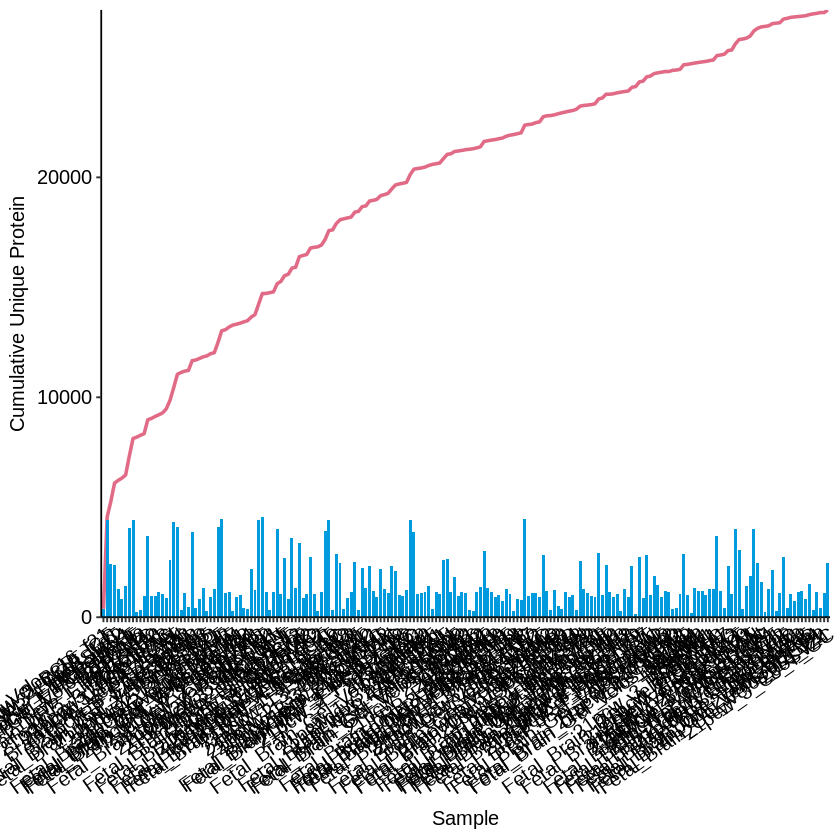

In [94]:
output_path <- "../../figures/cumu_heatmap"
##### Saturation Plot #####
# sample_order <- sample(sample_metadata$Sample)
# sample_order <- sample_metadata %>% arrange(Enrichment,Enzyme,Replicate) %>% .$Sample
set.seed(123)
sample_order <- all_sample_sep_m_meta %>% .$Sample %>% unique() %>% sample()
# 1. 蛋白累积分析（带柱状图）
res_protein <- cumu_combo_plot(
  df = orfs,
  sample_order = sample_order,
  target_col = "Protein",
  show_bar = TRUE
)
head(res_protein$plot_data,1)
res_protein$version_sampleNum+  scale_x_continuous(expand = c(0, 0)) +
  scale_y_continuous(expand = c(0, 0)) -> p
res_protein$version_sampleName
ggsave(p,filename=o("cumu_pro_sample_n.pdf"),height = 5,width = 8)
ggsave(res_protein$version_sampleName,filename=o("cumu_pro_sample_name.pdf"),height = 5,width = 8)

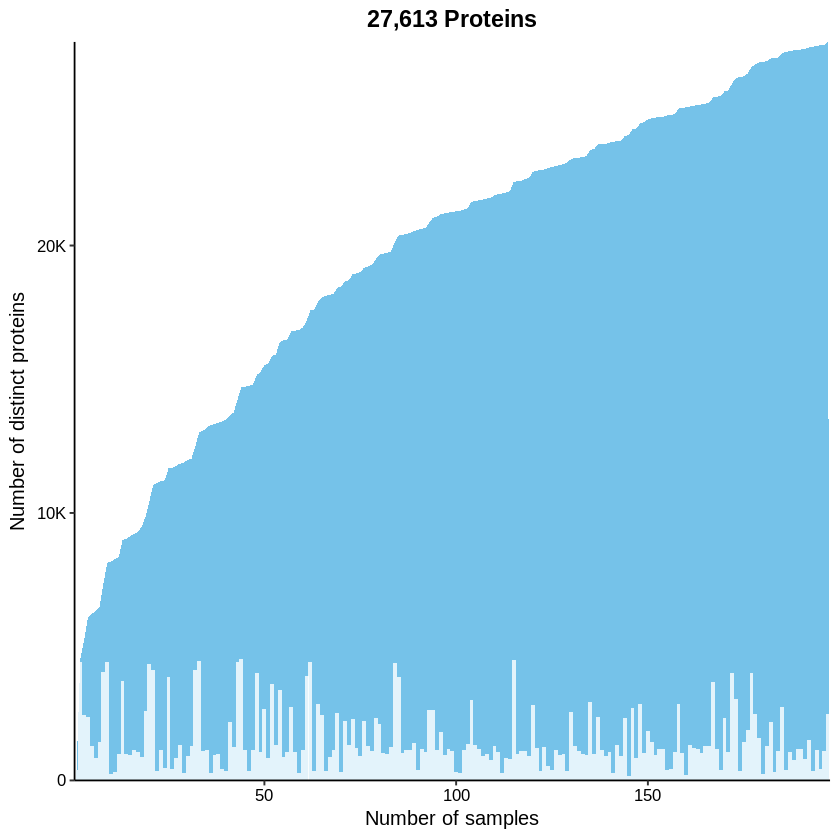

In [93]:
# 绘图
# d08e8f
cumulative_data=res_protein$plot_data
p <- ggplot(cumulative_data, aes(x = SampleCount, y = CumulativeUnique)) +
  geom_area(fill = "#1999da", alpha = 0.6) +  # 蓝灰色填充
  # 添加底部的条形图显示每个样本新增的肽段
  geom_col(aes(y = n), fill = "white", alpha = 0.8, width = 1) +
  labs(x = "Number of samples",
       y = "Number of distinct proteins",
       title = paste0(format(max(cumulative_data$CumulativeUnique), 
                            big.mark = ","), " Proteins")) +
  theme_3() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10),
    panel.grid.minor = element_blank()
  ) +
  scale_y_continuous(
    labels = function(x) {
      ifelse(x >= 1e6, paste0(x/1e6, "M"), 
             ifelse(x >= 1e3, paste0(x/1e3, "K"), x))
    },
    expand = c(0, 0)
  ) +
  scale_x_continuous(expand = c(0, 0))

# 显示图形
print(p)

# 保存图形
ggsave(p, filename=o("cumu_pro_sample_n_fill.pdf"),
       width = 10, height = 6, dpi = 300, bg = "white")

In [126]:
summary(res_protein$plot_data$n)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    169     911    1147    1541    2206    4537 

# 不同样本鉴定到的蛋白质比较

## 不同富集方法&酶切方法数量比较

In [130]:
all_sample_sep_m_meta %>% group_by(Enrichment,Enzyme) %>% mutate(Protein_n=n_distinct(Protein)) %>% distinct(Enzyme,Enrichment,Protein_n) -> plot_tmp

In [174]:
plot_tmp

Enzyme,Enrichment,Protein_n
<chr>,<chr>,<int>
Trypsin,C8,4311
Trypsin_ArgC,C8,4253
Trypsin_AspN,C8,3817
Trypsin_Chymotrypsin,C8,3460
Trypsin_GluC,C8,3523
Trypsin_LysC,C8,4734
Trypsin_LysN,C8,3984
Trypsin,MWCO,3095
Trypsin_ArgC,MWCO,2799


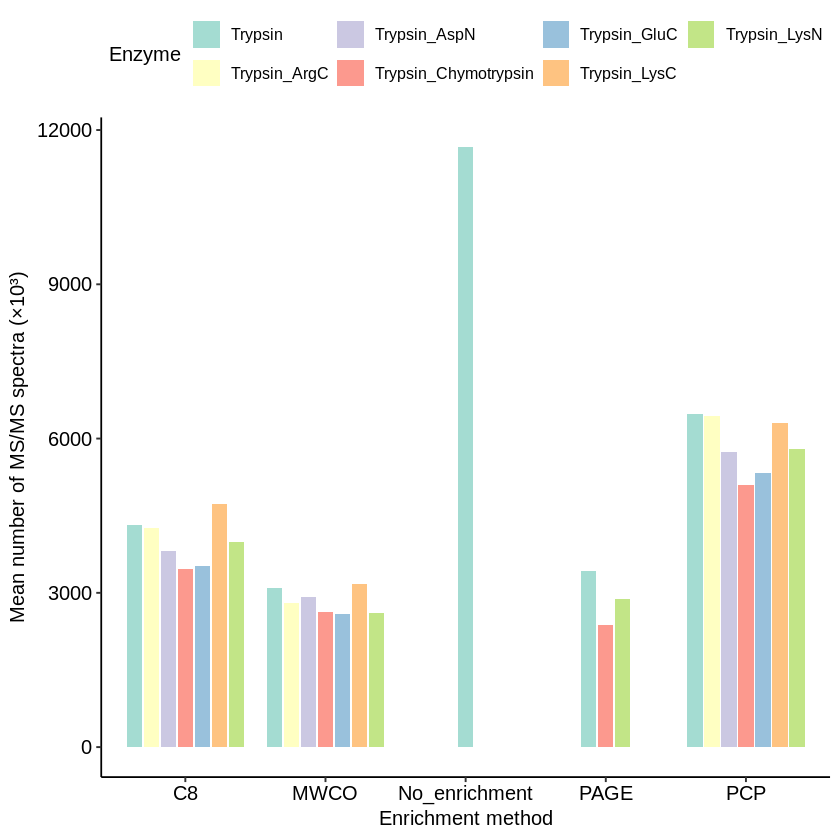

In [124]:
ggplot(plot_tmp, aes(x = Enrichment, y = Protein_n, fill = Enzyme)) +
  geom_bar(stat = "identity", position = position_dodge2(width = 1,preserve = "single"), width = 0.85, alpha = 0.8) +
  labs(x = "Enrichment method",
       y = "Mean number of MS/MS spectra (×10³)",
       fill = "Enzyme") +
  scale_fill_brewer(palette = "Set3") +
#   scale_y_continuous(expand = c(0, 0),breaks = c(0,50,100,150,200),
#                     limits=c(0,200)) +
  theme_3()

In [98]:
colnames(orfs)

[1] "Protein"                     "iBAQ_B"                     
 [3] "iBAQ_A"                      "Available"                  
 [5] "TotalIntensity"              "ORF_type"                   
 [7] "Start_codon"                 "Isoform_id"                 
 [9] "Chr"                         "Strand"                     
[11] "ORF_seq"                     "ORF_length"                 
[13] "Geneid"                      "Isoform_structural_category"
[15] "Isoform_subcategory"         "is_uniprot"                 
[17] "is_canonical"                "All_peptide_n"              
[19] "Unique_peptide_n"            "Theo_peptide_n"             
[21] "Sample"

## public和in house数据的比较

In [67]:
orfs %>% merge(sample_metadata,by = "Sample") -> orfs_m_meta
head(orfs_m_meta)

,Sample,Protein,iBAQ_B,iBAQ_A,Available,TotalIntensity,ORF_type,Start_codon,Isoform_id,Chr,⋯,Isoform_structural_category,Isoform_subcategory,is_uniprot,is_canonical,All_peptide_n,Unique_peptide_n,Theo_peptide_n,Enzyme,Period,Enrichment
,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<lgl>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1,108cortex1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,642360.77,2648746.90,TRUE,214548499,canonical,ATG,PB.10027.4,chr12,⋯,full-splice_match,reference_match,FALSE,TRUE,14,6,81,Trypsin,fetal,No_enrichment
2,108cortex1,PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG,31831.32,102331.81,TRUE,13814795,canonical,ATG,PB.10043.1,chr12,⋯,full-splice_match,reference_match,FALSE,TRUE,10,3,135,Trypsin,fetal,No_enrichment
3,108cortex1,PB.10158.2:chr12:+|6|1884:70:1042|canonical|ATG,10854.97,33076.94,TRUE,3506156,canonical,ATG,PB.10158.2,chr12,⋯,full-splice_match,alternative_5end,FALSE,TRUE,1,1,106,Trypsin,fetal,No_enrichment
4,108cortex1,PB.10267.490:chr12:+|3|5507:80:3137|canonical|ATG,216193.86,913217.22,TRUE,220085350,canonical,ATG,PB.10267.490,chr12,⋯,full-splice_match,reference_match,FALSE,TRUE,22,4,241,Trypsin,fetal,No_enrichment
5,108cortex1,PB.10305.46:chr12:-|121|2300:1834:1894|dORF|ATG,NA,NA,FALSE,NA,dORF,ATG,PB.10305.46,chr12,⋯,full-splice_match,alternative_3end,FALSE,FALSE,1,1,6,Trypsin,fetal,No_enrichment
6,108cortex1,PB.10426.8:chr12:+|2|2802:65:2408|canonical|ATG,3165951.21,12046058.25,TRUE,2469441941,canonical,ATG,PB.10426.8,chr12,⋯,full-splice_match,alternative_3end,FALSE,TRUE,8,5,205,Trypsin,fetal,No_enrichment


In [68]:
cols <- c("Protein","ORF_length","is_canonical","Enrichment")
orfs_m_meta[,cols] %>% head()
orfs_m_meta[,cols] -> orfs_m_meta_selected

,Protein,ORF_length,is_canonical,Enrichment
,<chr>,<int>,<lgl>,<chr>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,334,TRUE,No_enrichment
2,PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG,434,TRUE,No_enrichment
3,PB.10158.2:chr12:+|6|1884:70:1042|canonical|ATG,323,TRUE,No_enrichment
4,PB.10267.490:chr12:+|3|5507:80:3137|canonical|ATG,1018,TRUE,No_enrichment
5,PB.10305.46:chr12:-|121|2300:1834:1894|dORF|ATG,19,FALSE,No_enrichment
6,PB.10426.8:chr12:+|2|2802:65:2408|canonical|ATG,780,TRUE,No_enrichment


In [190]:
# canonical蛋白质的比例
proportion_data <- orfs_m_meta_selected %>% distinct() %>% 
  group_by(Enrichment, is_canonical) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(Enrichment) %>%
  mutate(total = sum(count),
         proportion = count / total,
         percentage = proportion * 100)
proportion_data

Enrichment,is_canonical,count,total,proportion,percentage
<chr>,<lgl>,<int>,<int>,<dbl>,<dbl>
C8,FALSE,5422,11653,0.4652879,46.52879
C8,TRUE,6231,11653,0.5347121,53.47121
MWCO,FALSE,2696,7248,0.3719647,37.19647
MWCO,TRUE,4552,7248,0.6280353,62.80353
No_enrichment,FALSE,5080,11663,0.4355655,43.55655
No_enrichment,TRUE,6583,11663,0.5644345,56.44345
PAGE,FALSE,1520,5087,0.2988009,29.88009
PAGE,TRUE,3567,5087,0.7011991,70.11991
PCP,FALSE,7898,15335,0.5150310,51.50310


### 粗看版本


Attaching package: ‘scales’


The following object is masked from ‘package:tidyfst’:

    percent




[1] "列联表："
               
                FALSE  TRUE
  Enrichment    17536 21787
  No_enrichment  5080  6583
[1] "Fisher检验结果："

	Fisher's Exact Test for Count Data

data:  contingency_table
p-value = 0.04841
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.000251 1.087642
sample estimates:
odds ratio 
  1.043034 

[1] "比例数据："
# A tibble: 4 × 6
# Groups:   Enrichment_group [2]
  Enrichment_group is_canonical count total proportion percentage
  <chr>            <lgl>        <int> <int>      <dbl>      <dbl>
1 Enrichment       FALSE        17536 39323      0.446       44.6
2 Enrichment       TRUE         21787 39323      0.554       55.4
3 No_enrichment    FALSE         5080 11663      0.436       43.6
4 No_enrichment    TRUE          6583 11663      0.564       56.4
[1] "ORF_length描述统计："
# A tibble: 2 × 7
  Enrichment_group     n  mean median    sd   min   max
  <chr>            <int> <dbl>  <int> <dbl> <int> <int>
1 Enrichment       39323  3

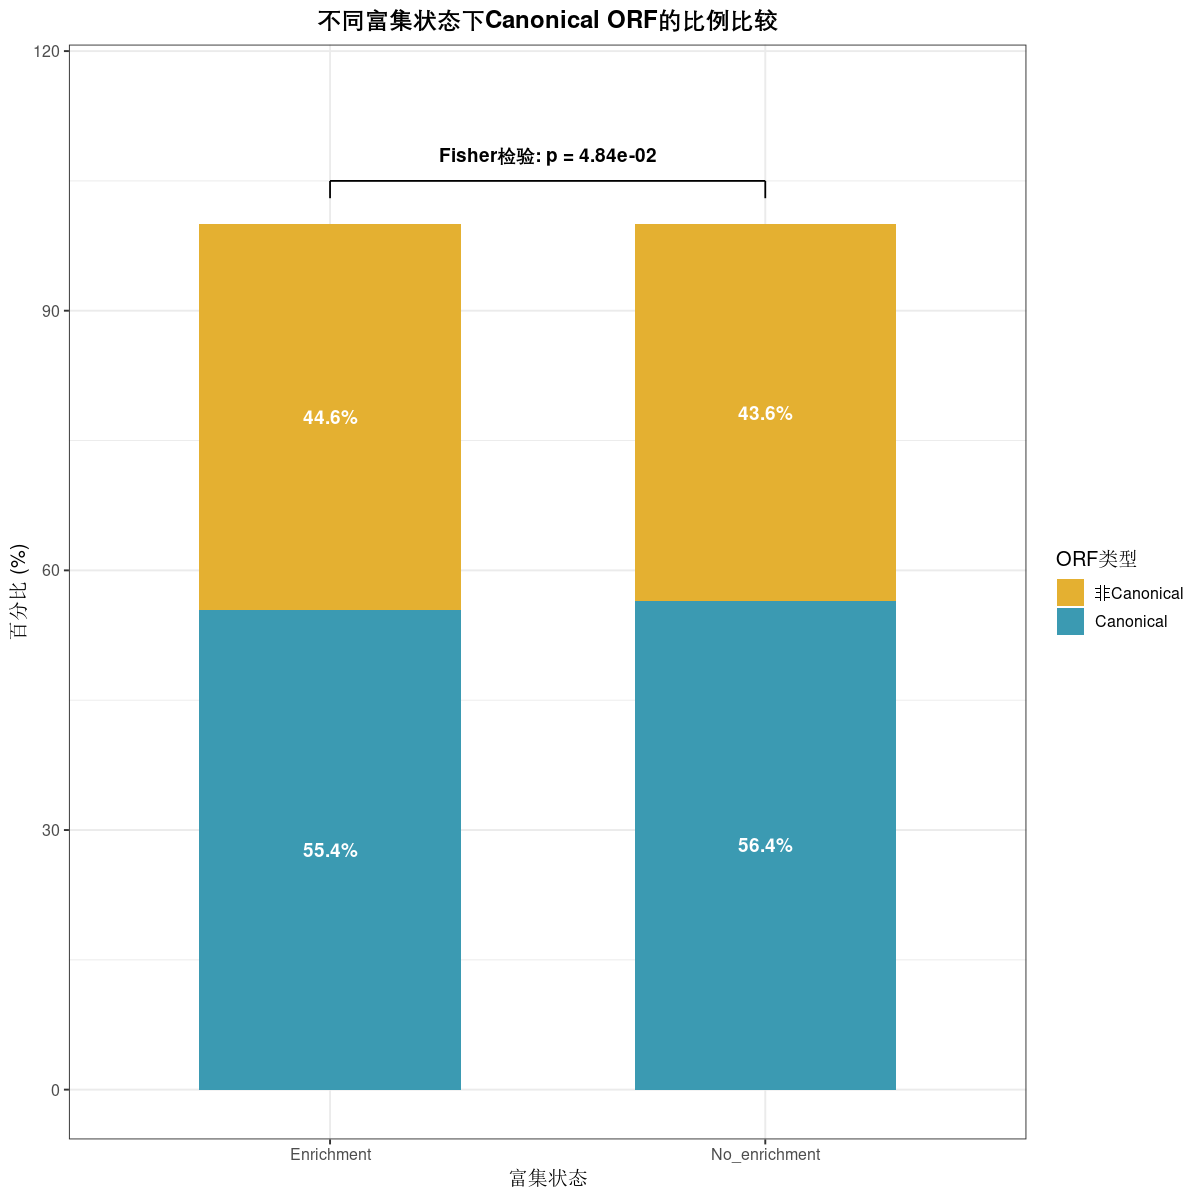

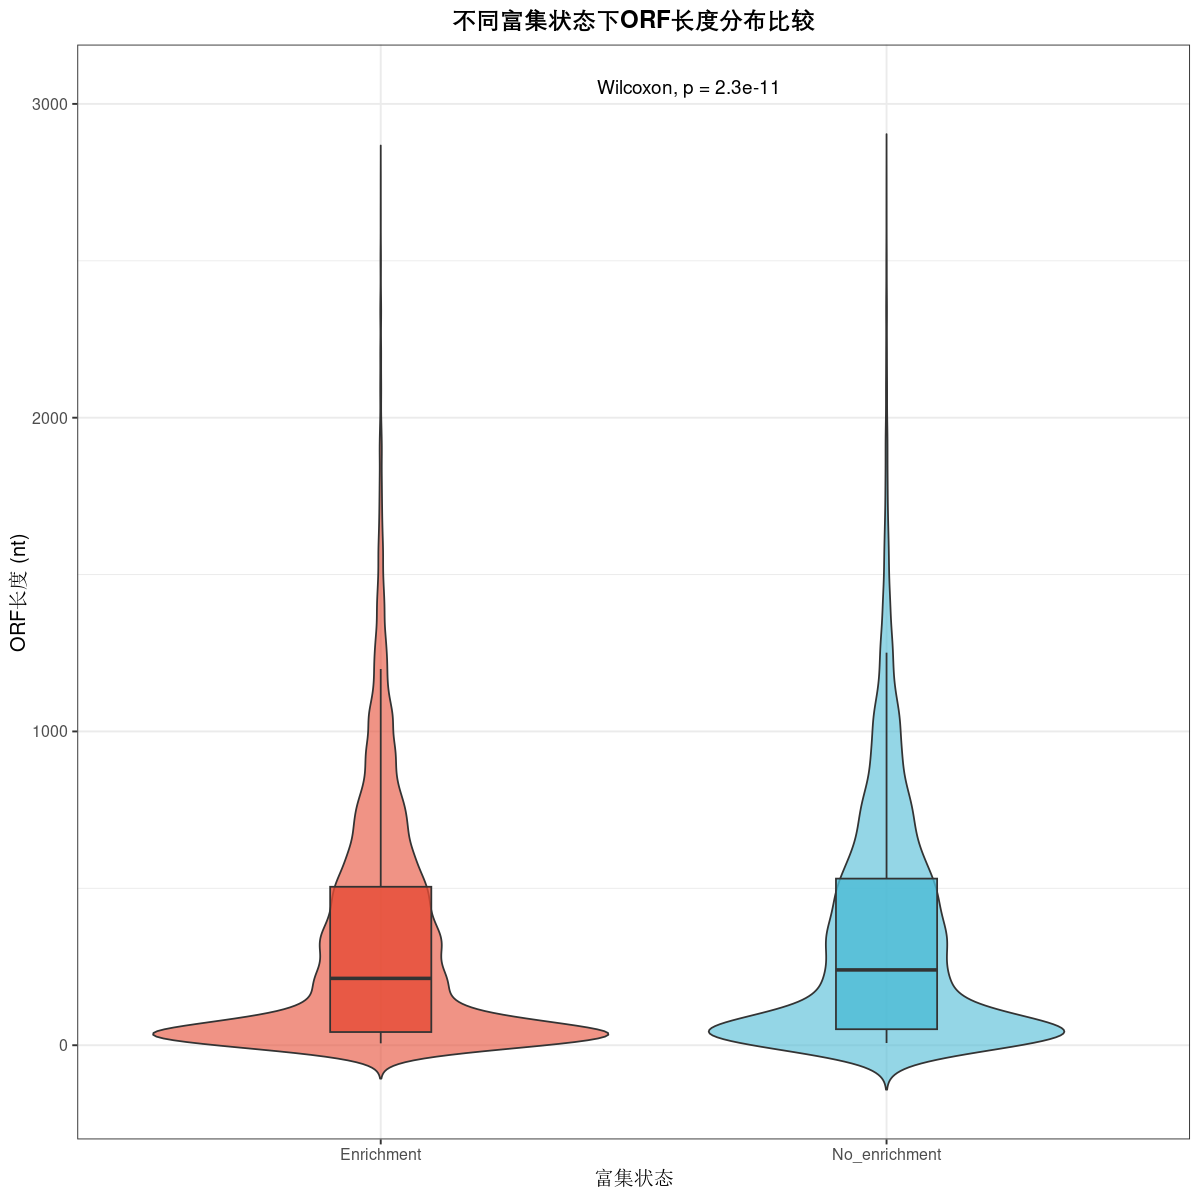


========== 统计分析结果摘要 ==========
1. Fisher精确检验 (is_canonical比例):
   p值 = 4.8407e-02
   比值比 = 1.0430
   结论: 两组比例有显著差异

2. Wilcoxon秩和检验 (ORF_length分布):
   p值 = 2.3336e-11
   结论: 两组长度分布有显著差异

3. 韦恩图统计:
   仅富集组: 15950
   仅非富集组: 3747
   交集: 7916


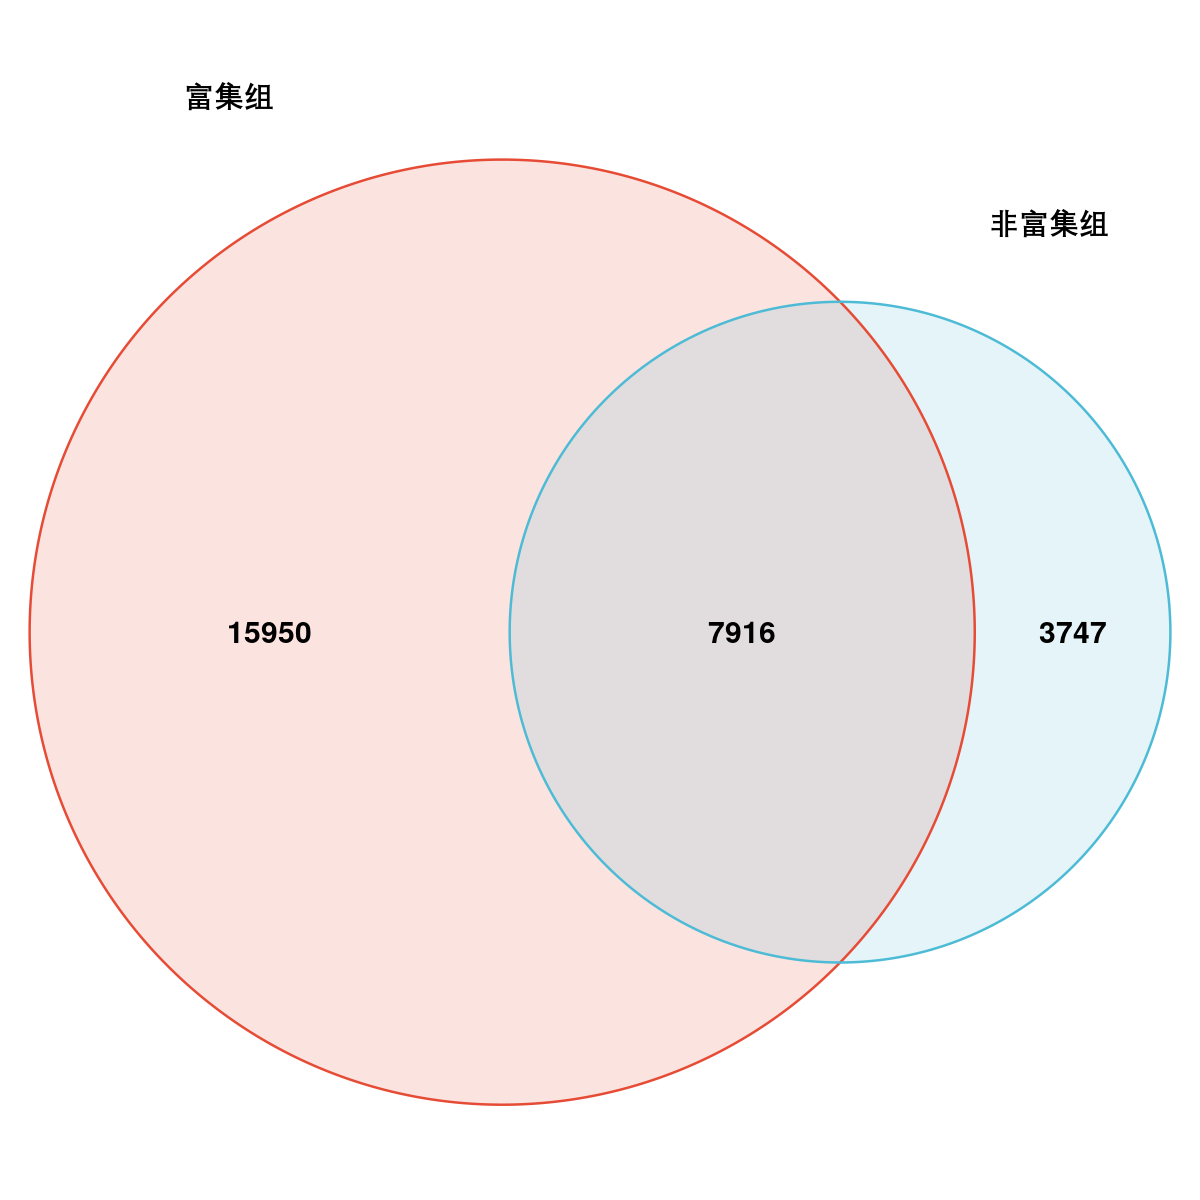

In [172]:
# 加载必要的包
library(dplyr)
library(ggplot2)
library(VennDiagram)
library(ggpubr)
library(scales)

# 1. 数据处理：创建新的Enrichment分组列
orfs_m_meta <- orfs_m_meta_selected %>%
  mutate(Enrichment_group = ifelse(Enrichment == "No_enrichment", 
                                    "No_enrichment", 
                                    "Enrichment")) %>%
  distinct()

# 2. 比较is_canonical的比例
# 创建列联表
contingency_table <- table(orfs_m_meta$Enrichment_group, 
                           orfs_m_meta$is_canonical)
print("列联表：")
print(contingency_table)

# Fisher精确检验
fisher_result <- fisher.test(contingency_table)
print("Fisher检验结果：")
print(fisher_result)

# 计算比例数据用于绘图
proportion_data <- orfs_m_meta %>%
  group_by(Enrichment_group, is_canonical) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(Enrichment_group) %>%
  mutate(total = sum(count),
         proportion = count / total,
         percentage = proportion * 100)

print("比例数据：")
print(proportion_data)

# 3. 绘制比例柱状图
p1 <- ggplot(proportion_data, aes(x = Enrichment_group, y = percentage, 
                                   fill = is_canonical)) +
  geom_bar(stat = "identity", position = "stack", width = 0.6) +
  geom_text(aes(label = sprintf("%.1f%%", percentage)),
            position = position_stack(vjust = 0.5), 
            size = 4, color = "white", fontface = "bold") +
  scale_fill_manual(values = c("TRUE" = "#3B9AB2", "FALSE" = "#E4B031"),
                    labels = c("FALSE" = "非Canonical", "TRUE" = "Canonical")) +
  labs(x = "富集状态", 
       y = "百分比 (%)",
       fill = "ORF类型",
       title = "不同富集状态下Canonical ORF的比例比较") +
  theme_bw(base_size = 12) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5),
        legend.position = "right",
        plot.title = element_text(hjust = 0.5, face = "bold")) +
  # 添加显著性标注
  annotate("segment", x = 1, xend = 2, y = 105, yend = 105, 
           color = "black", size = 0.5) +
  annotate("segment", x = 1, xend = 1, y = 105, yend = 103, 
           color = "black", size = 0.5) +
  annotate("segment", x = 2, xend = 2, y = 105, yend = 103, 
           color = "black", size = 0.5) +
  annotate("text", x = 1.5, y = 108, 
           label = sprintf("Fisher检验: p = %.2e", fisher_result$p.value),
           size = 4, fontface = "bold") +
  ylim(0, 115)

print(p1)

# 4. 比较ORF_length分布
# 首先查看数据分布
print("ORF_length描述统计：")
print(orfs_m_meta %>%
  group_by(Enrichment_group) %>%
  summarise(
    n = n(),
    mean = mean(ORF_length),
    median = median(ORF_length),
    sd = sd(ORF_length),
    min = min(ORF_length),
    max = max(ORF_length)
  ))

# Shapiro-Wilk正态性检验（如果样本量不太大）
if(nrow(orfs_m_meta) < 5000) {
  print("正态性检验：")
  by(orfs_m_meta$ORF_length, orfs_m_meta$Enrichment_group, shapiro.test)
}

# 使用Wilcoxon秩和检验（Mann-Whitney U检验）- 更稳健
wilcox_result <- wilcox.test(ORF_length ~ Enrichment_group, 
                              data = orfs_m_meta)
print("Wilcoxon秩和检验结果：")
print(wilcox_result)

# 绘制ORF_length分布比较图（箱线图+小提琴图）
p2 <- ggplot(orfs_m_meta, aes(x = Enrichment_group, y = ORF_length, 
                               fill = Enrichment_group)) +
  geom_violin(alpha = 0.6, trim = FALSE) +
  geom_boxplot(width = 0.2, alpha = 0.8, outlier.shape = NA) +
  scale_fill_manual(values = c("Enrichment" = "#E64B35", 
                               "No_enrichment" = "#4DBBD5")) +
  labs(x = "富集状态",
       y = "ORF长度 (nt)",
       title = "不同富集状态下ORF长度分布比较") +
  theme_bw(base_size = 12) +
  theme(legend.position = "none",
        plot.title = element_text(hjust = 0.5, face = "bold")) +
  stat_compare_means(method = "wilcox.test", 
                     label.x = 1.5, 
                     label.y = max(orfs_m_meta$ORF_length) * 1.1,
                     size = 4)

print(p2)

# 5. 绘制韦恩图
# 提取两个组别的Protein ID集合
enrichment_ids <- orfs_m_meta %>%
  filter(Enrichment_group == "Enrichment") %>%
  pull(Protein)

no_enrichment_ids <- orfs_m_meta %>%
  filter(Enrichment_group == "No_enrichment") %>%
  pull(Protein)

# 创建韦恩图
venn.plot <- venn.diagram(
  x = list(
    Enrichment = enrichment_ids,
    No_enrichment = no_enrichment_ids
  ),
  category.names = c("富集组", "非富集组"),
  filename = NULL,
  output = TRUE,
  
  # 图形参数
  height = 3000,
  width = 3000,
  resolution = 300,
  
  # 圆圈
  lwd = 2,
  lty = 'solid',
  col = c("#E64B35", "#4DBBD5"),
  fill = c(alpha("#E64B35", 0.3), alpha("#4DBBD5", 0.3)),
  
  # 数字
  cex = 1.5,
  fontface = "bold",
  fontfamily = "sans",
  
  # 标签
  cat.cex = 1.5,
  cat.fontface = "bold",
  cat.default.pos = "outer",
  cat.pos = c(-27, 27),
  cat.dist = c(0.055, 0.055),
  cat.fontfamily = "sans"
)

# 显示韦恩图
grid.newpage()
grid.draw(venn.plot)

# 6. 合并图形
# library(patchwork)
# combined_plot <- p1 / p2 + 
#   plot_annotation(tag_levels = 'A',
#                   title = 'ORF富集状态分析',
#                   theme = theme(plot.title = element_text(hjust = 0.5, 
#                                                           size = 16, 
#                                                           face = "bold")))
# print(combined_plot)

# 7. 输出统计结果摘要
cat("\n========== 统计分析结果摘要 ==========\n")
cat(sprintf("1. Fisher精确检验 (is_canonical比例):\n"))
cat(sprintf("   p值 = %.4e\n", fisher_result$p.value))
cat(sprintf("   比值比 = %.4f\n", fisher_result$estimate))
cat(sprintf("   结论: %s\n", 
            ifelse(fisher_result$p.value < 0.05, "两组比例有显著差异", "两组比例无显著差异")))

cat(sprintf("\n2. Wilcoxon秩和检验 (ORF_length分布):\n"))
cat(sprintf("   p值 = %.4e\n", wilcox_result$p.value))
cat(sprintf("   结论: %s\n", 
            ifelse(wilcox_result$p.value < 0.05, "两组长度分布有显著差异", "两组长度分布无显著差异")))

cat(sprintf("\n3. 韦恩图统计:\n"))
cat(sprintf("   仅富集组: %d\n", length(setdiff(enrichment_ids, no_enrichment_ids))))
cat(sprintf("   仅非富集组: %d\n", length(setdiff(no_enrichment_ids, enrichment_ids))))
cat(sprintf("   交集: %d\n", length(intersect(enrichment_ids, no_enrichment_ids))))

In [189]:
# 2. 提取两组的Protein ID
orfs_m_meta <- orfs_m_meta_selected %>%
  mutate(Enrichment_group = ifelse(Enrichment == "No_enrichment", 
                                    "No_enrichment", 
                                    "Enrichment")) %>%
  distinct()
enrichment_ids <- orfs_m_meta %>%
  filter(Enrichment_group == "Enrichment") %>%
  pull(Protein)

no_enrichment_ids <- orfs_m_meta %>%
  filter(Enrichment_group == "No_enrichment") %>%  
  pull(Protein)

# 3. 计算交集和各自特有的ORF
intersection_ids <- intersect(enrichment_ids, no_enrichment_ids)
enrichment_only_ids <- setdiff(enrichment_ids, no_enrichment_ids)
no_enrichment_only_ids <- setdiff(no_enrichment_ids, enrichment_ids)
# length(enrichment_only_ids)
# length(intersection_ids)

# 4. 统计各区域的经典/非经典蛋白数量
sum(grepl("canonical",intersection_ids))/length(intersection_ids)
sum(grepl("canonical",enrichment_only_ids))/length(enrichment_only_ids)
sum(grepl("canonical",no_enrichment_only_ids))/length(no_enrichment_only_ids)

[1] 0.7574533

[1] 0.2099687

[1] 0.1566587

### clean version

#### venn plot 

In [69]:
orfs %>% merge(sample_metadata,by = "Sample") -> orfs_m_meta
head(orfs_m_meta)
cols <- c("Protein","ORF_length","is_canonical","Enrichment")
orfs_m_meta[,cols] %>% head()
orfs_m_meta[,cols] -> orfs_m_meta_selected
df <- orfs_m_meta_selected %>%
  mutate(Enrichment_group = ifelse(Enrichment == "No_enrichment", 
                                    "No_enrichment", 
                                    "Enrichment")) %>%
  distinct()

,Sample,Protein,iBAQ_B,iBAQ_A,Available,TotalIntensity,ORF_type,Start_codon,Isoform_id,Chr,⋯,Isoform_structural_category,Isoform_subcategory,is_uniprot,is_canonical,All_peptide_n,Unique_peptide_n,Theo_peptide_n,Enzyme,Period,Enrichment
,<chr>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<lgl>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<chr>
1,108cortex1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,642360.77,2648746.90,TRUE,214548499,canonical,ATG,PB.10027.4,chr12,⋯,full-splice_match,reference_match,FALSE,TRUE,14,6,81,Trypsin,fetal,No_enrichment
2,108cortex1,PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG,31831.32,102331.81,TRUE,13814795,canonical,ATG,PB.10043.1,chr12,⋯,full-splice_match,reference_match,FALSE,TRUE,10,3,135,Trypsin,fetal,No_enrichment
3,108cortex1,PB.10158.2:chr12:+|6|1884:70:1042|canonical|ATG,10854.97,33076.94,TRUE,3506156,canonical,ATG,PB.10158.2,chr12,⋯,full-splice_match,alternative_5end,FALSE,TRUE,1,1,106,Trypsin,fetal,No_enrichment
4,108cortex1,PB.10267.490:chr12:+|3|5507:80:3137|canonical|ATG,216193.86,913217.22,TRUE,220085350,canonical,ATG,PB.10267.490,chr12,⋯,full-splice_match,reference_match,FALSE,TRUE,22,4,241,Trypsin,fetal,No_enrichment
5,108cortex1,PB.10305.46:chr12:-|121|2300:1834:1894|dORF|ATG,NA,NA,FALSE,NA,dORF,ATG,PB.10305.46,chr12,⋯,full-splice_match,alternative_3end,FALSE,FALSE,1,1,6,Trypsin,fetal,No_enrichment
6,108cortex1,PB.10426.8:chr12:+|2|2802:65:2408|canonical|ATG,3165951.21,12046058.25,TRUE,2469441941,canonical,ATG,PB.10426.8,chr12,⋯,full-splice_match,alternative_3end,FALSE,TRUE,8,5,205,Trypsin,fetal,No_enrichment


,Protein,ORF_length,is_canonical,Enrichment
,<chr>,<int>,<lgl>,<chr>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,334,TRUE,No_enrichment
2,PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG,434,TRUE,No_enrichment
3,PB.10158.2:chr12:+|6|1884:70:1042|canonical|ATG,323,TRUE,No_enrichment
4,PB.10267.490:chr12:+|3|5507:80:3137|canonical|ATG,1018,TRUE,No_enrichment
5,PB.10305.46:chr12:-|121|2300:1834:1894|dORF|ATG,19,FALSE,No_enrichment
6,PB.10426.8:chr12:+|2|2802:65:2408|canonical|ATG,780,TRUE,No_enrichment


In [71]:
enrichment_ids <- df %>%
  filter(Enrichment_group == "Enrichment") %>%
  pull(Protein)
head(enrichment_ids)
no_enrichment_ids <- df %>%
  filter(Enrichment_group == "No_enrichment") %>%
  pull(Protein)
head(no_enrichment_ids)
venn_plot_n(list(Enrichment=enrichment_ids,No_enrichment=no_enrichment_ids),auto_scale = T,set_name_size = 6) -> p
ggsave(p,filename=o("public_in_house_overlap.pdf"),height = 5,width = 8)

[1] "PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG" 
[2] "PB.1003.3:chr1:+|10|581:117:393|canonical|ATG"     
[3] "PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG"  
[4] "PB.1009.1:chr1:-|10|2772:187:838|canonical|ATG"    
[5] "PB.10167.18:chr12:+|20|2518:201:1527|canonical|ATG"
[6] "PB.10216.11:chr12:+|30|2937:422:2675|noncoding|ATG"

[1] "PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG"
[2] "PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG" 
[3] "PB.10158.2:chr12:+|6|1884:70:1042|canonical|ATG"  
[4] "PB.10267.490:chr12:+|3|5507:80:3137|canonical|ATG"
[5] "PB.10305.46:chr12:-|121|2300:1834:1894|dORF|ATG"  
[6] "PB.10426.8:chr12:+|2|2802:65:2408|canonical|ATG"

ERROR: Error in dir.exists(output_path): object 'output_path' not found


#### 长度比例分组分bin

In [41]:
head(df)

,Protein,ORF_length,is_canonical,Enrichment,Enrichment_group,length_bin
,<chr>,<int>,<lgl>,<chr>,<chr>,<fct>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,334,TRUE,No_enrichment,No_enrichment,"[300,350)"
2,PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG,434,TRUE,No_enrichment,No_enrichment,"[400,450)"
3,PB.10158.2:chr12:+|6|1884:70:1042|canonical|ATG,323,TRUE,No_enrichment,No_enrichment,"[300,350)"
4,PB.10267.490:chr12:+|3|5507:80:3137|canonical|ATG,1018,TRUE,No_enrichment,No_enrichment,"[1e+03,1.05e+03)"
5,PB.10305.46:chr12:-|121|2300:1834:1894|dORF|ATG,19,FALSE,No_enrichment,No_enrichment,"[0,50)"
6,PB.10426.8:chr12:+|2|2802:65:2408|canonical|ATG,780,TRUE,No_enrichment,No_enrichment,"[750,800)"


In [40]:
print("ORF_length描述统计：")
print(df %>%
  group_by(Enrichment_group) %>%
  summarise(
    n = n(),
    mean = mean(ORF_length),
    median = median(ORF_length),
    sd = sd(ORF_length),
    min = min(ORF_length),
    max = max(ORF_length)
  ))
# 使用Wilcoxon秩和检验（Mann-Whitney U检验）- 更稳健
wilcox_result <- wilcox.test(ORF_length ~ Enrichment_group, 
                              data = df)
print("Wilcoxon秩和检验结果：")
print(wilcox_result)

[1] "ORF_length描述统计："
# A tibble: 2 × 7
  Enrichment_group     n  mean median    sd   min   max
  <chr>            <int> <dbl>  <int> <dbl> <int> <int>
1 Enrichment       39323  335.    213  370.     6  2755
2 No_enrichment    11663  354.    240  374.     7  2755
[1] "Wilcoxon秩和检验结果："

	Wilcoxon rank sum test with continuity correction

data:  ORF_length by Enrichment_group
W = 219982414, p-value = 2.334e-11
alternative hypothesis: true location shift is not equal to 0



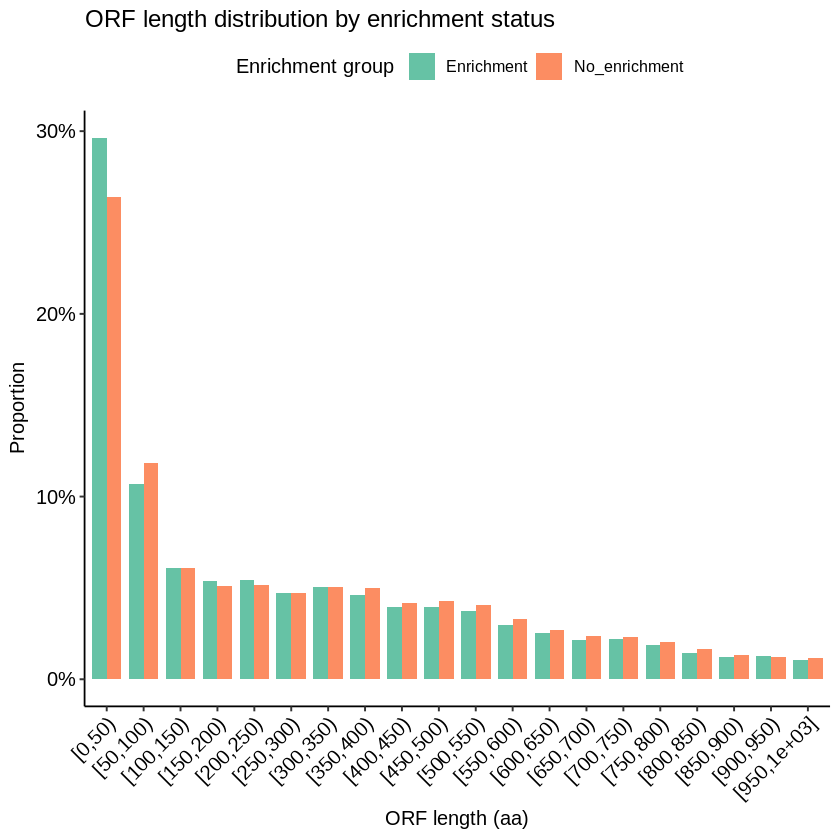

In [29]:
library(ggplot2)
library(cowplot)

# 创建 bin 分组，只保留 ORF_length < 1000 的数据
df_filtered <- df %>%
  filter(ORF_length < 1000) %>%
  mutate(length_bin = cut(ORF_length, 
                          breaks = seq(0, 1000, by = 50),
                          include.lowest = TRUE,
                          right = FALSE))

# 计算每个 bin 的相对比例
df_binned_prop <- df_filtered %>%
  group_by(Enrichment_group, length_bin) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(Enrichment_group) %>%
  mutate(proportion = count / sum(count))

# 绘制相对比例柱状图
p_length_prop <- ggplot(df_binned_prop, aes(x = length_bin, y = proportion, fill = Enrichment_group)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.8) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    x = "ORF length (aa)",
    y = "Proportion",
    title = "ORF length distribution by enrichment status",
    fill = "Enrichment group"
  ) +
  theme_3() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  scale_y_continuous(labels = scales::percent_format())

p_length_prop

# ggsave(o("orf_length_distribution_proportion_0_1000.pdf"), p_length_prop, width = 10, height = 6)

In [30]:
# library(ggplot2)
# library(cowplot)

# # 创建 bin 分组
# df <- df %>%
#   mutate(length_bin = cut(ORF_length, 
#                           breaks = seq(0, max(ORF_length, na.rm = TRUE) + 50, by = 50),
#                           include.lowest = TRUE,
#                           right = FALSE))

# # 计算每个 bin 的计数
# df_binned <- df %>%
#   group_by(Enrichment_group, length_bin) %>%
#   summarise(count = n(), .groups = "drop")

# # 绘制分组柱状图
# p_length_hist <- ggplot(df_binned, aes(x = length_bin, y = count, fill = Enrichment_group)) +
#   geom_bar(stat = "identity", position = "dodge", width = 0.8) +
#   scale_fill_brewer(palette = "Set2") +
#   labs(
#     x = "ORF length (aa)",
#     y = "Count",
#     title = "ORF length distribution by enrichment status",
#     fill = "Enrichment group"
#   ) +
#   theme_3() +
#   theme(
#     axis.text.x = element_text(angle = 45, hjust = 1)
#   )

# p_length_hist

# # ggsave(o("orf_length_distribution_bins.pdf"), p_length_hist, width = 10, height = 6)

In [25]:
head(df_binned_prop)

Enrichment_group,length_bin,count,proportion
<chr>,<fct>,<int>,<dbl>
Enrichment,"[0,50)",10915,0.27757292
Enrichment,"[50,100)",3933,0.10001780
Enrichment,"[100,150)",2248,0.05716756
Enrichment,"[150,200)",1973,0.05017420
Enrichment,"[200,250)",2006,0.05101340
Enrichment,"[250,300)",1730,0.04399461


### 细分比较

In [42]:
cols <- c("Protein","ORF_length","is_canonical","Enrichment","Sample")
orfs_m_meta[,cols] %>% head()
orfs_m_meta[,cols] -> orfs_m_meta_selected

,Protein,ORF_length,is_canonical,Enrichment,Sample
,<chr>,<int>,<lgl>,<chr>,<chr>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,334,TRUE,No_enrichment,108cortex1
2,PB.10043.1:chr12:+|7|1792:131:1436|canonical|ATG,434,TRUE,No_enrichment,108cortex1
3,PB.10158.2:chr12:+|6|1884:70:1042|canonical|ATG,323,TRUE,No_enrichment,108cortex1
4,PB.10267.490:chr12:+|3|5507:80:3137|canonical|ATG,1018,TRUE,No_enrichment,108cortex1
5,PB.10305.46:chr12:-|121|2300:1834:1894|dORF|ATG,19,FALSE,No_enrichment,108cortex1
6,PB.10426.8:chr12:+|2|2802:65:2408|canonical|ATG,780,TRUE,No_enrichment,108cortex1


In [53]:
mutate(orfs_m_meta_selected,Enrichment_group = case_when(
    grepl("Fetal_Brain_bRP",Sample) ~ "bRP_fractioned",
    grepl("Fetal_Brain_Gel",Sample) ~ "Gel_fractioned",
    Enrichment!="No_enrichment" ~ "Enrichment",
    TRUE ~ Enrichment
),
     Enrichment_group_1 = case_when(
    grepl("Fetal_Brain",Sample) ~ "Fractioned",
    Enrichment!="No_enrichment" ~ "Enrichment",
    TRUE ~ Enrichment
) ) -> orfs_m_meta_selected_add
orfs_m_meta_selected_add %>% select(-Sample) %>% distinct() -> df

[1] "Enrichment"    "Fractioned"    "No_enrichment"

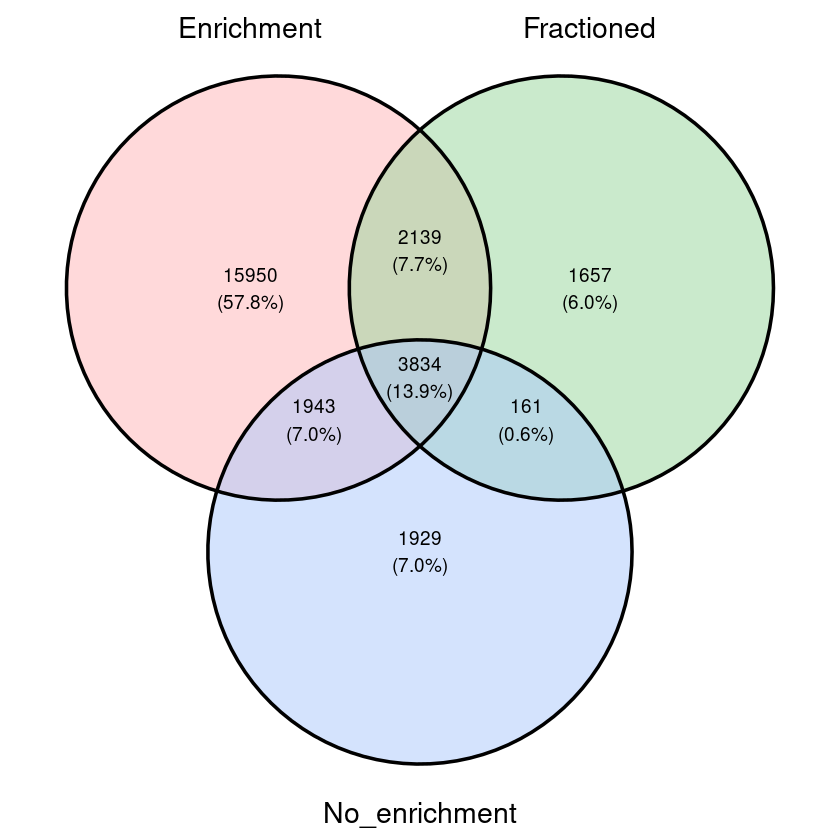

In [65]:
split(df$Protein, df$Enrichment_group_1) -> l
# table(df$Enrichment_group_1)
names(l) <- c('Enrichment','Fractioned','No_enrichment')
names(l)
venn_plot_n(l,auto_scale = T,set_name_size = 6)

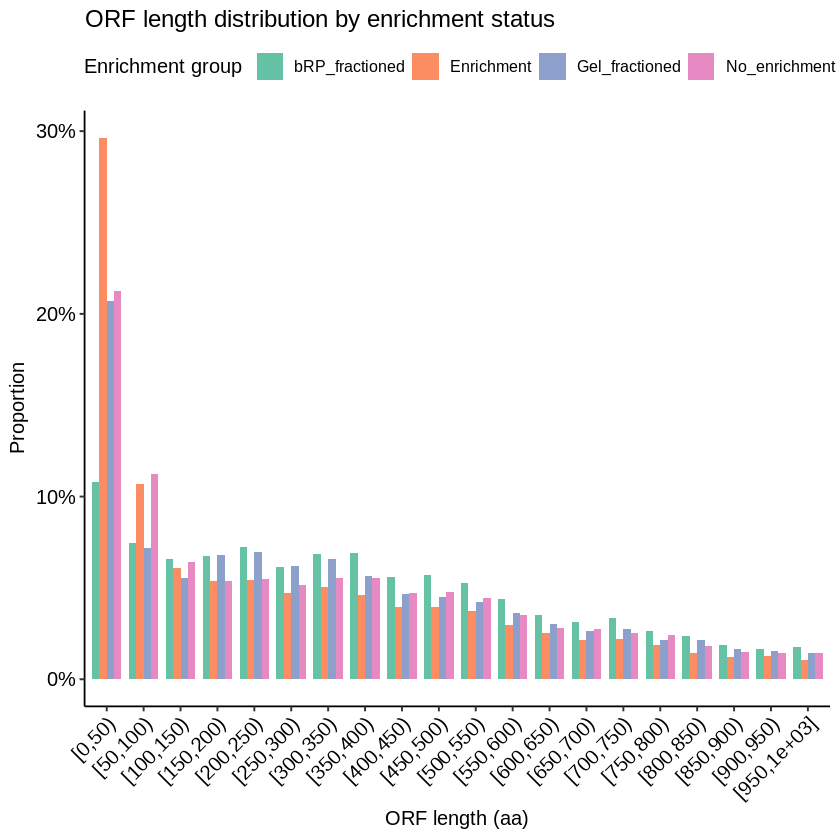

In [50]:
library(ggplot2)
library(cowplot)

# 创建 bin 分组，只保留 ORF_length < 1000 的数据
df_filtered <- df %>%
  filter(ORF_length < 1000) %>%
  mutate(length_bin = cut(ORF_length, 
                          breaks = seq(0, 1000, by = 50),
                          include.lowest = TRUE,
                          right = FALSE))

# 计算每个 bin 的相对比例
df_binned_prop <- df_filtered %>%
  group_by(Enrichment_group, length_bin) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(Enrichment_group) %>%
  mutate(proportion = count / sum(count))

# 绘制相对比例柱状图
p_length_prop <- ggplot(df_binned_prop, aes(x = length_bin, y = proportion, fill = Enrichment_group)) +
  geom_bar(stat = "identity", position = "dodge", width = 0.8) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    x = "ORF length (aa)",
    y = "Proportion",
    title = "ORF length distribution by enrichment status",
    fill = "Enrichment group"
  ) +
  theme_3() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  ) +
  scale_y_continuous(labels = scales::percent_format())

p_length_prop

# ggsave(o("orf_length_distribution_proportion_0_1000.pdf"), p_length_prop, width = 10, height = 6)

# 被不同技术重复支持的次数

In [129]:
# cus_plot <- function(df){
#     # 查看蛋白在一种富集方法一种酶切方法中重复被检测到的次数
#     count(df,Protein,Enzyme,Enrichment) %>% 
#     group_by(Enzyme,Enrichment) %>% 
#     count(n) -> df_1
#     library(ggplot2)
#     ggplot(df_1, aes(x=factor(n), y=nn, fill=Enzyme)) +
#     geom_bar(stat='identity', position='dodge') +
#       scale_fill_brewer(palette = "Set3") +
#     facet_wrap(~Enrichment) +
#     labs(x='Number of technical replicates (same enrichment & digestion condition)\nsupporting protein existence', y='Frequency')+
#     theme_3() -> p
#     return(p)
# }
# all_sample_sep_m_meta %>% 
# all_sample_sep_m_meta %>% filter(grepl("^sp",Protein) |grepl("canonical",Protein)) -> all_sample_sep_m_meta_cano
# n_distinct(all_sample_sep_m_meta_cano$Protein)
# all_sample_sep_m_meta %>% filter(grepl("^PB",Protein) & !grepl("canonical",Protein))  -> all_sample_sep_m_meta_uncano
# n_distinct(all_sample_sep_m_meta_uncano$Protein)
# cus_plot(all_sample_sep_m_meta_cano) -> p
# ggsave(p,filename=o("enrichmen_enzyme_tech_replicate_n_cano_protein.pdf"),height = 5,width = 8)
# cus_plot(all_sample_sep_m_meta_uncano) -> p
# ggsave(p,filename=o("enrichmen_enzyme_tech_replicate_n_uncano_protein.pdf"),height = 5,width = 8)

# 热图

In [76]:
output_path <- "../../figures/cumu_heatmap"
merge_replicate <- function(df){
    # 合并重复
    df$Sample_merge_replicate <- gsub("21pcw(_1|_2|_3)", "21pcw", df$Sample)
    distinct(df,Protein,Sample_merge_replicate,Enzyme,Enrichment) -> df_1
    df_1 %>% rename(Sample=Sample_merge_replicate) -> df_2
    return(df_2)
}
define_type <- function(x){
    return(if_else(grepl("^sp",x) |grepl("canonical",x),"Cano","Uncano"))
}
mutate(all_sample_sep_m_meta,Sample=case_when(
    grepl("21pcw",Sample) ~ Sample,
    TRUE ~ "In_house_brain"
)) -> all_sample_sep_m_meta_1
df <- merge_replicate(all_sample_sep_m_meta_1)
protein_stats <- df %>%
  group_by(Protein) %>%
  summarise(
    Unique_Methods = n_distinct(Enrichment),  # 被多少种不同富集方法鉴定到
    Total_Observations = n(),                 # 被鉴定到的总次数
    Supported_Enrichments = paste(sort(unique(Enrichment)), collapse = ", ")  # 支持的富集方法（去重后逗号分隔）
  )
protein_stats$Unique_Methods <- as.character(protein_stats$Unique_Methods)
protein_stats$Unique_Methods <- factor(protein_stats$Unique_Methods,levels=c('5','4','3','2','1'))
protein_stats$Type <- factor(define_type(protein_stats$Protein),levels = c("Cano","Uncano"))
protein_stats %>% arrange(Type,Unique_Methods, Supported_Enrichments,desc(Total_Observations)) -> protein_stats

In [77]:
n_distinct(df$Sample)

[1] 25

Warning message in brewer.pal(length(unique(protein_stats$Type)), "Set3"):
“minimal value for n is 3, returning requested palette with 3 different levels
”
'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



png 
  2

[1] "2x2列联表:"
                  
                    Cano Uncano
  Unique_Methods=1  2569  14134
  Unique_Methods>1  5601   3486
[1] "\n卡方检验结果:"

	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 5816.1, df = 1, p-value < 2.2e-16

[1] "\n期望频数:"
                  
                       Cano    Uncano
  Unique_Methods=1 5291.334 11411.666
  Unique_Methods>1 2878.666  6208.334


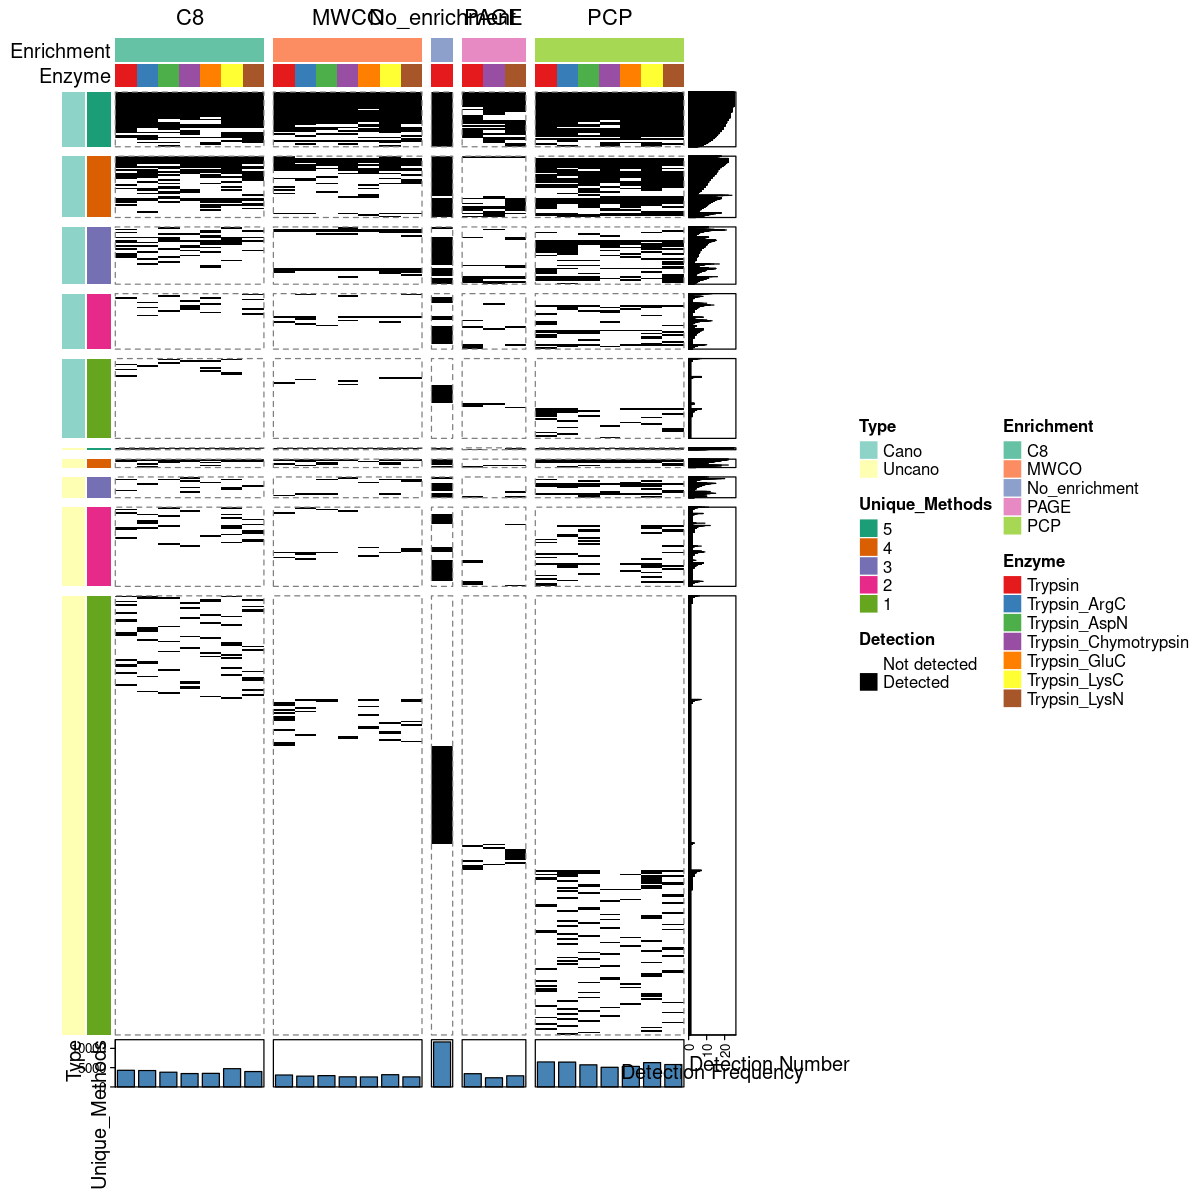

In [78]:
library(ComplexHeatmap)
library(circlize)
# Create a binary detection matrix
binary_matrix_tmp <- df %>%
  mutate(present = 1) %>%
  select(Sample, Protein, present) %>%
  pivot_wider(names_from = Sample, values_from = present, values_fill = 0) %>%
  column_to_rownames("Protein") %>%
  as.matrix()
# 按照特定顺序排序
binary_matrix_tmp[protein_stats$Protein,] -> binary_matrix
# Calculate detection frequency for each protein
detection_freq <- rowSums(binary_matrix)
detection_number <- colSums(binary_matrix)

# Get unique sample annotations
sample_annot <- df %>%
  select(Sample,Enrichment,Enzyme) %>%
  distinct() %>%
  column_to_rownames("Sample")

# Define colors for annotations
enzyme_colors <- setNames(brewer.pal(length(unique(sample_annot$Enzyme)), "Set1"), 
                          unique(sample_annot$Enzyme))
enrichment_colors <- setNames(brewer.pal(length(unique(sample_annot$Enrichment)), "Set2"), 
                              unique(sample_annot$Enrichment))
# Create column annotations
col_ha <- HeatmapAnnotation(
  df = sample_annot,
  col = list(
    Enzyme = enzyme_colors,
    Enrichment = enrichment_colors
  ),
  annotation_name_side = "left"
)

# Create row annotation for detection frequency
row_ha <- rowAnnotation(
  "Detection Frequency" = anno_barplot(detection_freq, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)
col_ha_1 <- columnAnnotation(
  "Detection Number" = anno_barplot(detection_number, 
                                       bar_width = 0.8,
                                       gp = gpar(fill = "steelblue",col=NULL))
)

# Define colors for annotations
type_colors <- setNames(brewer.pal(length(unique(protein_stats$Type)), "Set3"), 
                          unique(protein_stats$Type))
method_colors <- setNames(brewer.pal(length(unique(protein_stats$Unique_Methods)), "Dark2"), 
                              unique(protein_stats$Unique_Methods))
protein_stats[,c("Type","Unique_Methods")]  %>% as.data.frame() -> row_anno
rownames(row_anno) <- protein_stats$Protein
# Create column annotations
row_ha_1 <- rowAnnotation(
  df = row_anno,
  col = list(
    Type = type_colors[1:2],
    Unique_Methods = method_colors
  ),
  annotation_name_side = "bottom"
)

column_split <- factor(
  sample_annot$Enrichment, 
  levels = unique(sample_annot$Enrichment) 
)
groups <- paste0(protein_stats$Type,"-",protein_stats$Unique_Methods)
row_split <- factor(
    groups, 
    levels = unique(groups)
)

options(repr.plot.width = 10, repr.plot.height = 10)
ht <- Heatmap(
    binary_matrix,
    name = "Detection",
    col = c("white", "black"),
    cluster_columns = FALSE,
    clustering_distance_columns="binary",
    cluster_rows = FALSE,
    row_title=NULL,
    show_row_names = FALSE,
    show_column_names = FALSE,
    top_annotation = col_ha,
    right_annotation = row_ha,
    left_annotation = row_ha_1,
    bottom_annotation = col_ha_1,
    column_split = column_split,
    row_split = row_split,
    heatmap_legend_param = list(
        at = c(0, 1),
        labels = c("Not detected", "Detected")
    ),
    use_raster = TRUE,
    # 添加虚线分隔
    row_gap = unit(2, "mm"),
    column_gap = unit(2, "mm"),
    border_gp = gpar(lty = "dashed", col = "grey50")  # 替代方法
)
ht

# Draw the heatmap
# 1. 打开 PDF 设备，设置文件名和尺寸（单位：英寸）
pdf(o("protein_detection_heatmap.pdf"), width = 12, height = 12)
# 2. 绘制热图（假设 `ht` 是你的 Heatmap 对象）
draw(ht)
# 3. 关闭设备，保存文件
dev.off()

# 自动生成2x2列联表
library(dplyr)

# 创建分组变量
protein_stats_grouped <- protein_stats %>%
  mutate(
    Group = case_when(
      Unique_Methods == "1" ~ "Unique_Methods=1",
      Unique_Methods %in% c("2", "3", "4") ~ "Unique_Methods>1"
    )
  )

# 生成列联表
contingency_table <- table(protein_stats_grouped$Group, protein_stats_grouped$Type)
print("2x2列联表:")
print(contingency_table)

# 进行卡方检验
chi_test <- chisq.test(contingency_table)
print("\n卡方检验结果:")
print(chi_test)

# 检查期望频数
print("\n期望频数:")
print(chi_test$expected)

# 如果期望频数<5，使用Fisher精确检验
if(any(chi_test$expected < 5)) {
  print("\n期望频数<5，使用Fisher精确检验:")
  fisher_test <- fisher.test(contingency_table)
  print(fisher_test)
}

In [154]:
colnames(protein_stats_grouped)
protein_stats_grouped %>% group_by(Type,Unique_Methods) %>% summarise(n=n())

[1] "Protein"               "Unique_Methods"        "Total_Observations"   
[4] "Supported_Enrichments" "Type"                  "Group"

`summarise()` has grouped output by 'Type'. You can override using the
`.groups` argument.


Type,Unique_Methods,n
<fct>,<fct>,<int>
Cano,5,1762
Cano,4,1973
Cano,3,1843
Cano,2,1785
Cano,1,2569
Uncano,5,61
Uncano,4,269
Uncano,3,667
Uncano,2,2550
